# LieLines Predictions — Analysis

Analyses `sentence_corpus_predicted.csv` produced by `run_lielines.py`.
All heavy aggregations use chunked reads so the full 20 GB file is never loaded into memory.
Plots are produced from compact summary DataFrames.

In [20]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PRED_FILE  = '/home/tom/data/sentence_corpus_predicted.csv'
CHUNK_SIZE = 500_000

# Label values as stored in the CSV
LIE_LABEL    = 'LABEL_1'   # sentence IS a lie accusation
NOTLIE_LABEL = 'LABEL_0'   # sentence is NOT a lie accusation

print(f'File size: {os.path.getsize(PRED_FILE)/1e9:.2f} GB')

File size: 37.00 GB


## 1. Overview stats

In [21]:
total_rows  = 0
total_lies  = 0

for chunk in pd.read_csv(PRED_FILE, usecols=['lie_label'], chunksize=CHUNK_SIZE):
    total_rows += len(chunk)
    total_lies += (chunk['lie_label'] == LIE_LABEL).sum()

lie_rate = total_lies / total_rows
print(f'Total sentences : {total_rows:>15,}')
print(f'Flagged as lies : {total_lies:>15,}  ({lie_rate*100:.3f}%)')
print(f'Not flagged     : {total_rows - total_lies:>15,}')

Total sentences :     149,407,898
Flagged as lies :         532,268  (0.356%)
Not flagged     :     148,875,630


## 2. Lie rate by country

In [22]:
country_agg = {}   # country -> [total, lies]

for chunk in pd.read_csv(PRED_FILE, usecols=['country', 'lie_label'], chunksize=CHUNK_SIZE):
    chunk['is_lie'] = (chunk['lie_label'] == LIE_LABEL).astype(int)
    grp = chunk.groupby('country')['is_lie'].agg(['count', 'sum'])
    for country, row in grp.iterrows():
        if country not in country_agg:
            country_agg[country] = [0, 0]
        country_agg[country][0] += row['count']
        country_agg[country][1] += row['sum']

df_country = pd.DataFrame(
    [(k, v[0], v[1]) for k, v in country_agg.items()],
    columns=['country', 'total', 'lies']
).set_index('country')
df_country['lie_rate'] = df_country['lies'] / df_country['total']
df_country = df_country.sort_values('lie_rate', ascending=False)
print(df_country.to_string())

            total   lies  lie_rate
country                           
AU        7061204  49002  0.006940
HU        1754138  11779  0.006715
ES        4935516  30288  0.006137
NZ        6440641  38362  0.005956
GR        2808866  15895  0.005659
RS        2035132  10672  0.005244
CA        9412815  48741  0.005178
HR        4386165  20146  0.004593
PT        1128141   4716  0.004180
PL        2836437  11823  0.004168
AT        4095440  16724  0.004084
BA         999666   3971  0.003972
CZ        3678423  14512  0.003945
DE        6061925  21572  0.003559
US       24819557  85869  0.003460
GB       19636611  61804  0.003147
BG        1701921   5054  0.002970
IT        6055152  17724  0.002927
EE        1793124   3816  0.002128
LV         860723   1774  0.002061
DK        6027485  12022  0.001995
FR        2303057   4493  0.001951
IS        1774546   3087  0.001740
SE        7931243  12524  0.001579
NL       10901229  16759  0.001537
BE        2400011   3670  0.001529
FI         969618   

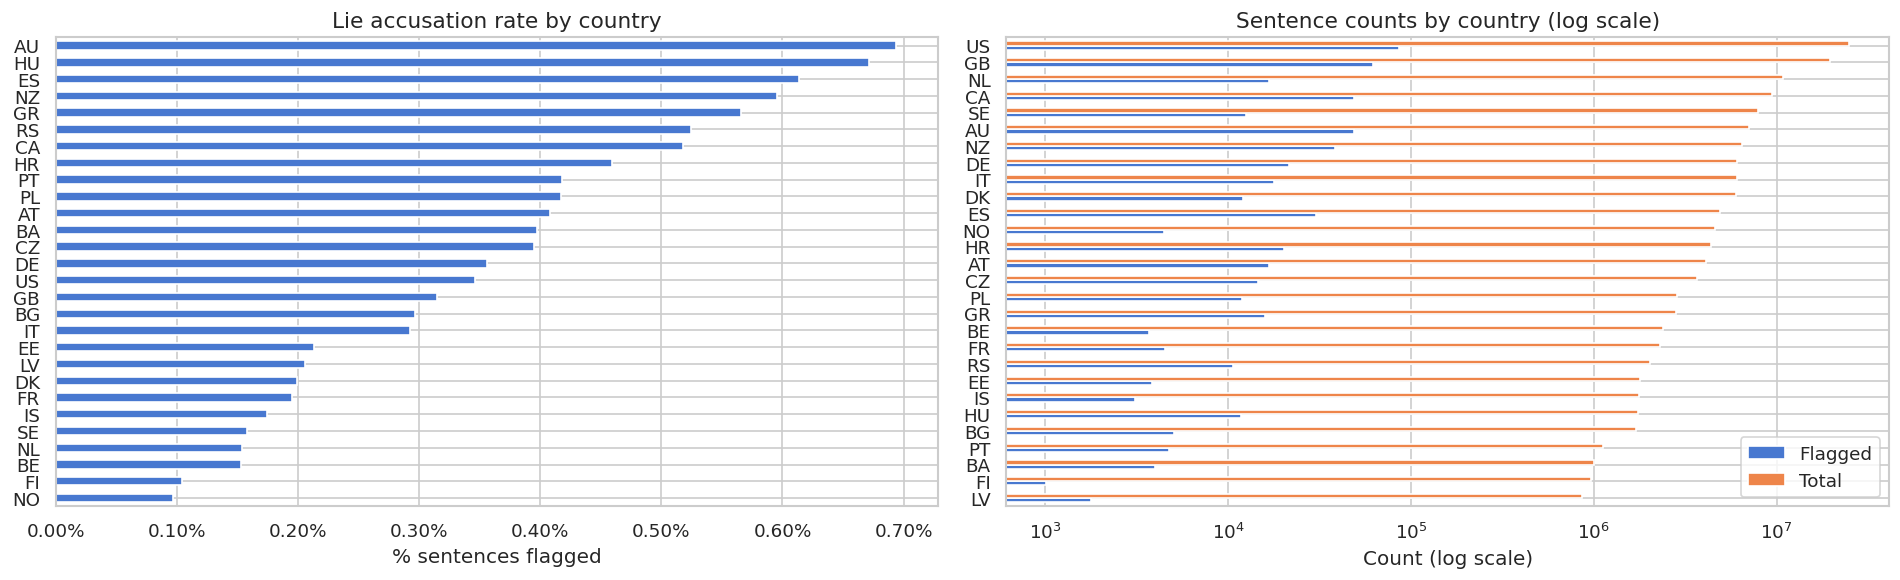

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: lie rate per country
ax = axes[0]
df_country['lie_rate'].sort_values(ascending=True).plot(
    kind='barh', ax=ax, color=sns.color_palette('muted')[0]
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=2))
ax.set_title('Lie accusation rate by country', fontsize=13)
ax.set_xlabel('% sentences flagged')
ax.set_ylabel('')

# Right: absolute counts (log scale)
ax2 = axes[1]
df_country[['lies', 'total']].sort_values('total', ascending=True).plot(
    kind='barh', ax=ax2, logx=True
)
ax2.set_title('Sentence counts by country (log scale)', fontsize=13)
ax2.set_xlabel('Count (log scale)')
ax2.set_ylabel('')
ax2.legend(['Flagged', 'Total'])

plt.tight_layout()
plt.savefig('lie_rate_by_country.png', bbox_inches='tight')
plt.show()

## 3. Lie rate over time (all countries combined)

In [24]:
year_agg = {}   # year -> [total, lies]

for chunk in pd.read_csv(PRED_FILE, usecols=['date', 'lie_label'], chunksize=CHUNK_SIZE):
    chunk['is_lie'] = (chunk['lie_label'] == LIE_LABEL).astype(int)
    chunk['year'] = pd.to_datetime(chunk['date'], errors='coerce').dt.year
    chunk = chunk.dropna(subset=['year'])
    chunk['year'] = chunk['year'].astype(int)
    grp = chunk.groupby('year')['is_lie'].agg(['count', 'sum'])
    for year, row in grp.iterrows():
        if year not in year_agg:
            year_agg[year] = [0, 0]
        year_agg[year][0] += row['count']
        year_agg[year][1] += row['sum']

df_time = pd.DataFrame(
    [(k, v[0], v[1]) for k, v in year_agg.items()],
    columns=['year', 'total', 'lies']
).set_index('year').sort_index()
df_time['lie_rate'] = df_time['lies'] / df_time['total']
print(df_time)

        total   lies  lie_rate
year                          
1987    48148    293  0.006085
1988   165749   1224  0.007385
1989   646512   3499  0.005412
1990  1121885   4772  0.004254
1991  1218328   5114  0.004198
1992  1524335   5670  0.003720
1993  1670972   6453  0.003862
1994  2227528   7725  0.003468
1995  3588380  12341  0.003439
1996  3200809  11435  0.003573
1997  3380009  11391  0.003370
1998  3946742  15644  0.003964
1999  4267610  15835  0.003711
2000  4354704  14619  0.003357
2001  4135519  13191  0.003190
2002  4036028  14091  0.003491
2003  4642450  16879  0.003636
2004  4503039  17945  0.003985
2005  4398184  16649  0.003785
2006  4209344  14881  0.003535
2007  4670421  15384  0.003294
2008  4407292  13799  0.003131
2009  5044335  17519  0.003473
2010  4598204  16282  0.003541
2011  4475578  14857  0.003320
2012  4550143  16641  0.003657
2013  4735775  17036  0.003597
2014  4325282  15406  0.003562
2015  6729885  20796  0.003090
2016  7137823  22220  0.003113
2017  72

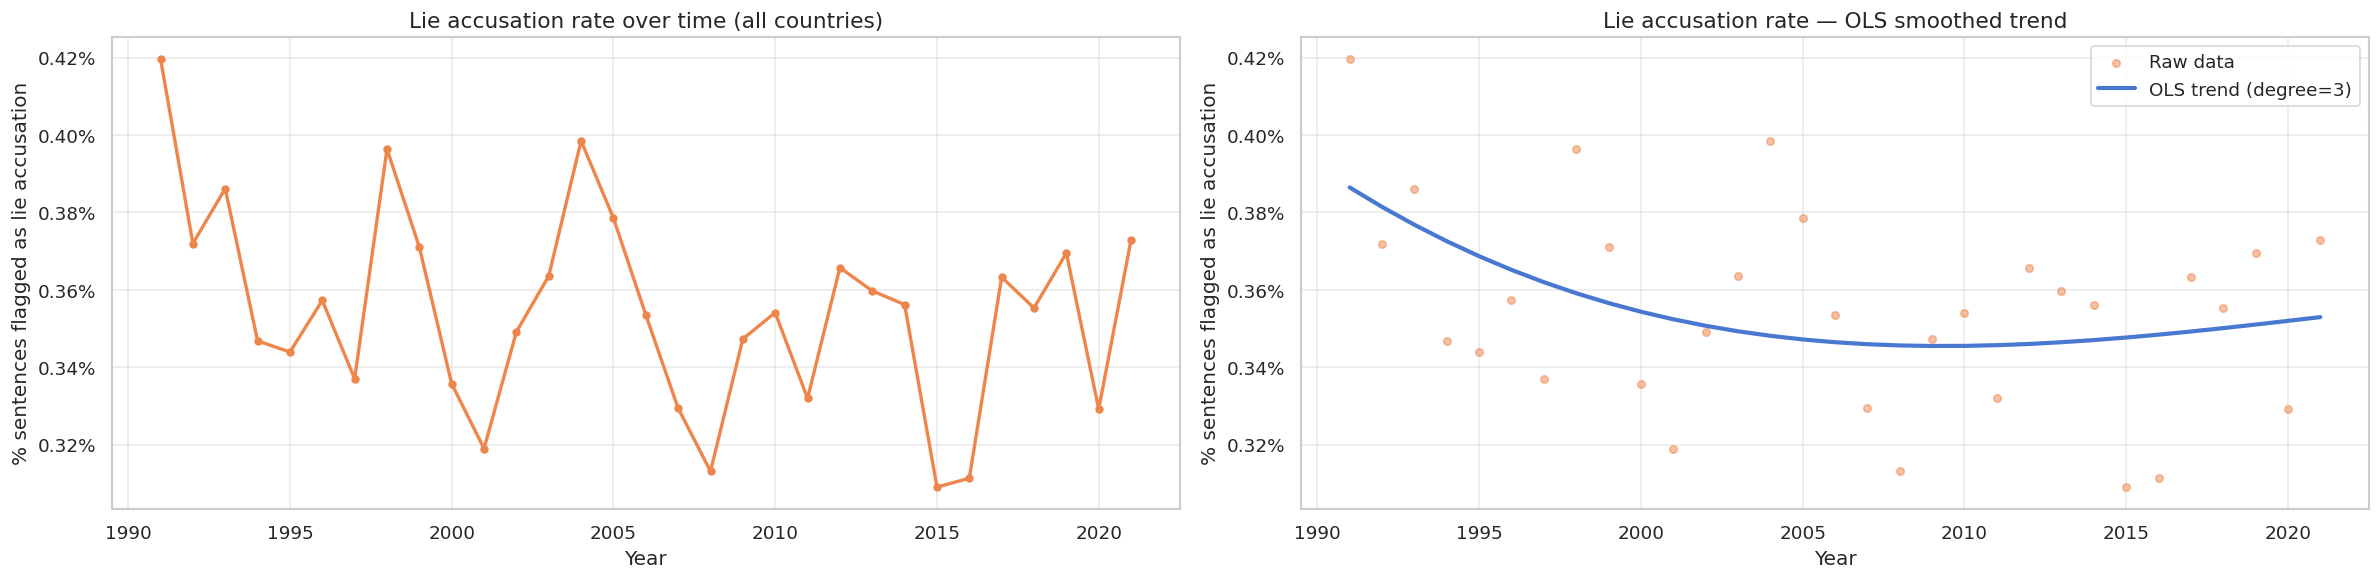

In [34]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Filter data: 1990–2022
df_filtered = df_time[(df_time.index > 1990) & (df_time.index < 2022)]

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# --- Chart 1: Raw data (original style) ---
ax = axes[0]
ax.plot(df_filtered.index, df_filtered['lie_rate'] * 100,
        marker='o', linewidth=2, markersize=4, color=sns.color_palette('muted')[1])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
ax.set_xlabel('Year')
ax.set_ylabel('% sentences flagged as lie accusation')
ax.set_title('Lie accusation rate over time (all countries)', fontsize=13)
ax.grid(True, alpha=0.4)

# --- Chart 2: OLS smoothed trend ---
ax2 = axes[1]

X = df_filtered.index.values.reshape(-1, 1)
y = df_filtered['lie_rate'].values * 100

# Optional: use polynomial degree > 1 for a curved fit
degree = 3
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)
model = LinearRegression().fit(X_poly, y)
y_pred = model.predict(X_poly)

# Plot raw points + OLS line
ax2.scatter(df_filtered.index, df_filtered['lie_rate'] * 100,
            s=20, alpha=0.5, color=sns.color_palette('muted')[1], label='Raw data')
ax2.plot(df_filtered.index, y_pred,
         linewidth=2.5, color=sns.color_palette('muted')[0], label=f'OLS trend (degree={degree})')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
ax2.set_xlabel('Year')
ax2.set_ylabel('% sentences flagged as lie accusation')
ax2.set_title('Lie accusation rate — OLS smoothed trend', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('lie_rate_over_time.png', bbox_inches='tight')
plt.show()

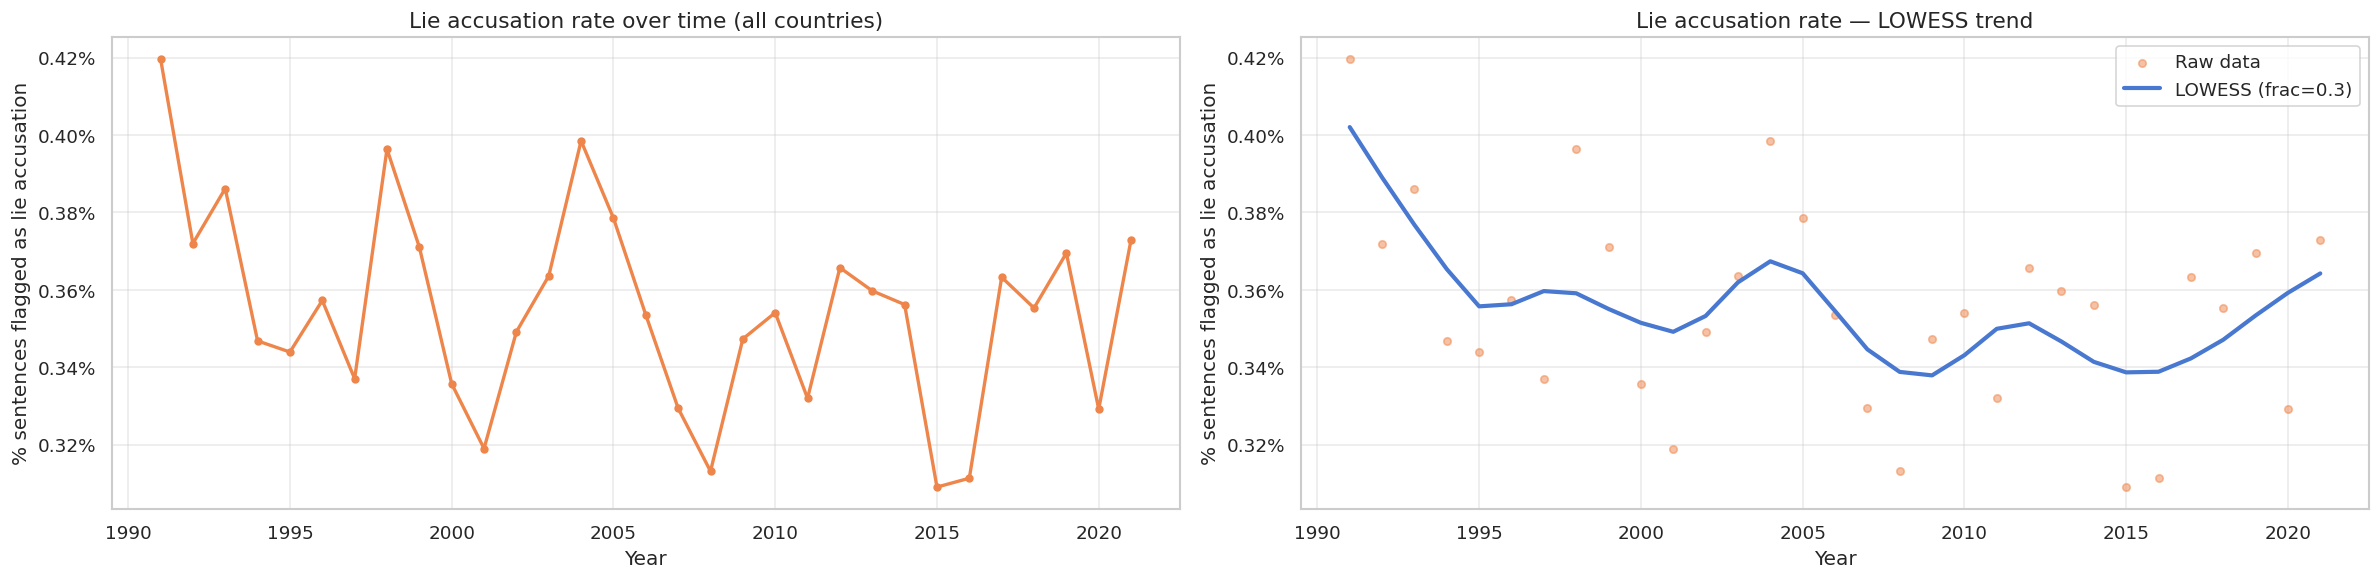

In [36]:
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# Filter data: 1990–2022
df_filtered = df_time[(df_time.index > 1990) & (df_time.index < 2022)]

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# --- Chart 1: Raw data (original style) ---
ax = axes[0]
ax.plot(df_filtered.index, df_filtered['lie_rate'] * 100,
        marker='o', linewidth=2, markersize=4, color=sns.color_palette('muted')[1])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
ax.set_xlabel('Year')
ax.set_ylabel('% sentences flagged as lie accusation')
ax.set_title('Lie accusation rate over time (all countries)', fontsize=13)
ax.grid(True, alpha=0.4)

# --- Chart 2: LOWESS smoothed trend ---
ax2 = axes[1]

y = df_filtered['lie_rate'].values * 100
x = df_filtered.index.values.astype(float)

# frac controls smoothing bandwidth — lower = more wiggly, higher = smoother
# 0.3 is a reasonable starting point; try 0.2–0.5
smoothed = lowess(y, x, frac=0.3, it=0)
x_smooth, y_smooth = smoothed[:, 0], smoothed[:, 1]

ax2.scatter(x, y, s=20, alpha=0.5, color=sns.color_palette('muted')[1], label='Raw data')
ax2.plot(x_smooth, y_smooth,
         linewidth=2.5, color=sns.color_palette('muted')[0], label='LOWESS (frac=0.3)')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
ax2.set_xlabel('Year')
ax2.set_ylabel('% sentences flagged as lie accusation')
ax2.set_title('Lie accusation rate — LOWESS trend', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('lie_rate_over_time.png', bbox_inches='tight')
plt.show()

## 4. Lie rate over time — per country

In [26]:
cy_agg = {}   # (country, year) -> [total, lies]

for chunk in pd.read_csv(PRED_FILE, usecols=['date', 'country', 'lie_label'], chunksize=CHUNK_SIZE):
    chunk['is_lie'] = (chunk['lie_label'] == LIE_LABEL).astype(int)
    chunk['year'] = pd.to_datetime(chunk['date'], errors='coerce').dt.year
    chunk = chunk.dropna(subset=['year'])
    chunk['year'] = chunk['year'].astype(int)
    grp = chunk.groupby(['country', 'year'])['is_lie'].agg(['count', 'sum'])
    for (country, year), row in grp.iterrows():
        key = (country, year)
        if key not in cy_agg:
            cy_agg[key] = [0, 0]
        cy_agg[key][0] += row['count']
        cy_agg[key][1] += row['sum']

df_cy = pd.DataFrame(
    [(k[0], k[1], v[0], v[1]) for k, v in cy_agg.items()],
    columns=['country', 'year', 'total', 'lies']
)
df_cy['lie_rate'] = df_cy['lies'] / df_cy['total']

# Only keep country-years with enough data to be meaningful
MIN_SENTENCES = 1000
df_cy = df_cy[df_cy['total'] >= MIN_SENTENCES]
print(f'Country-year combinations: {len(df_cy):,}')

Country-year combinations: 561


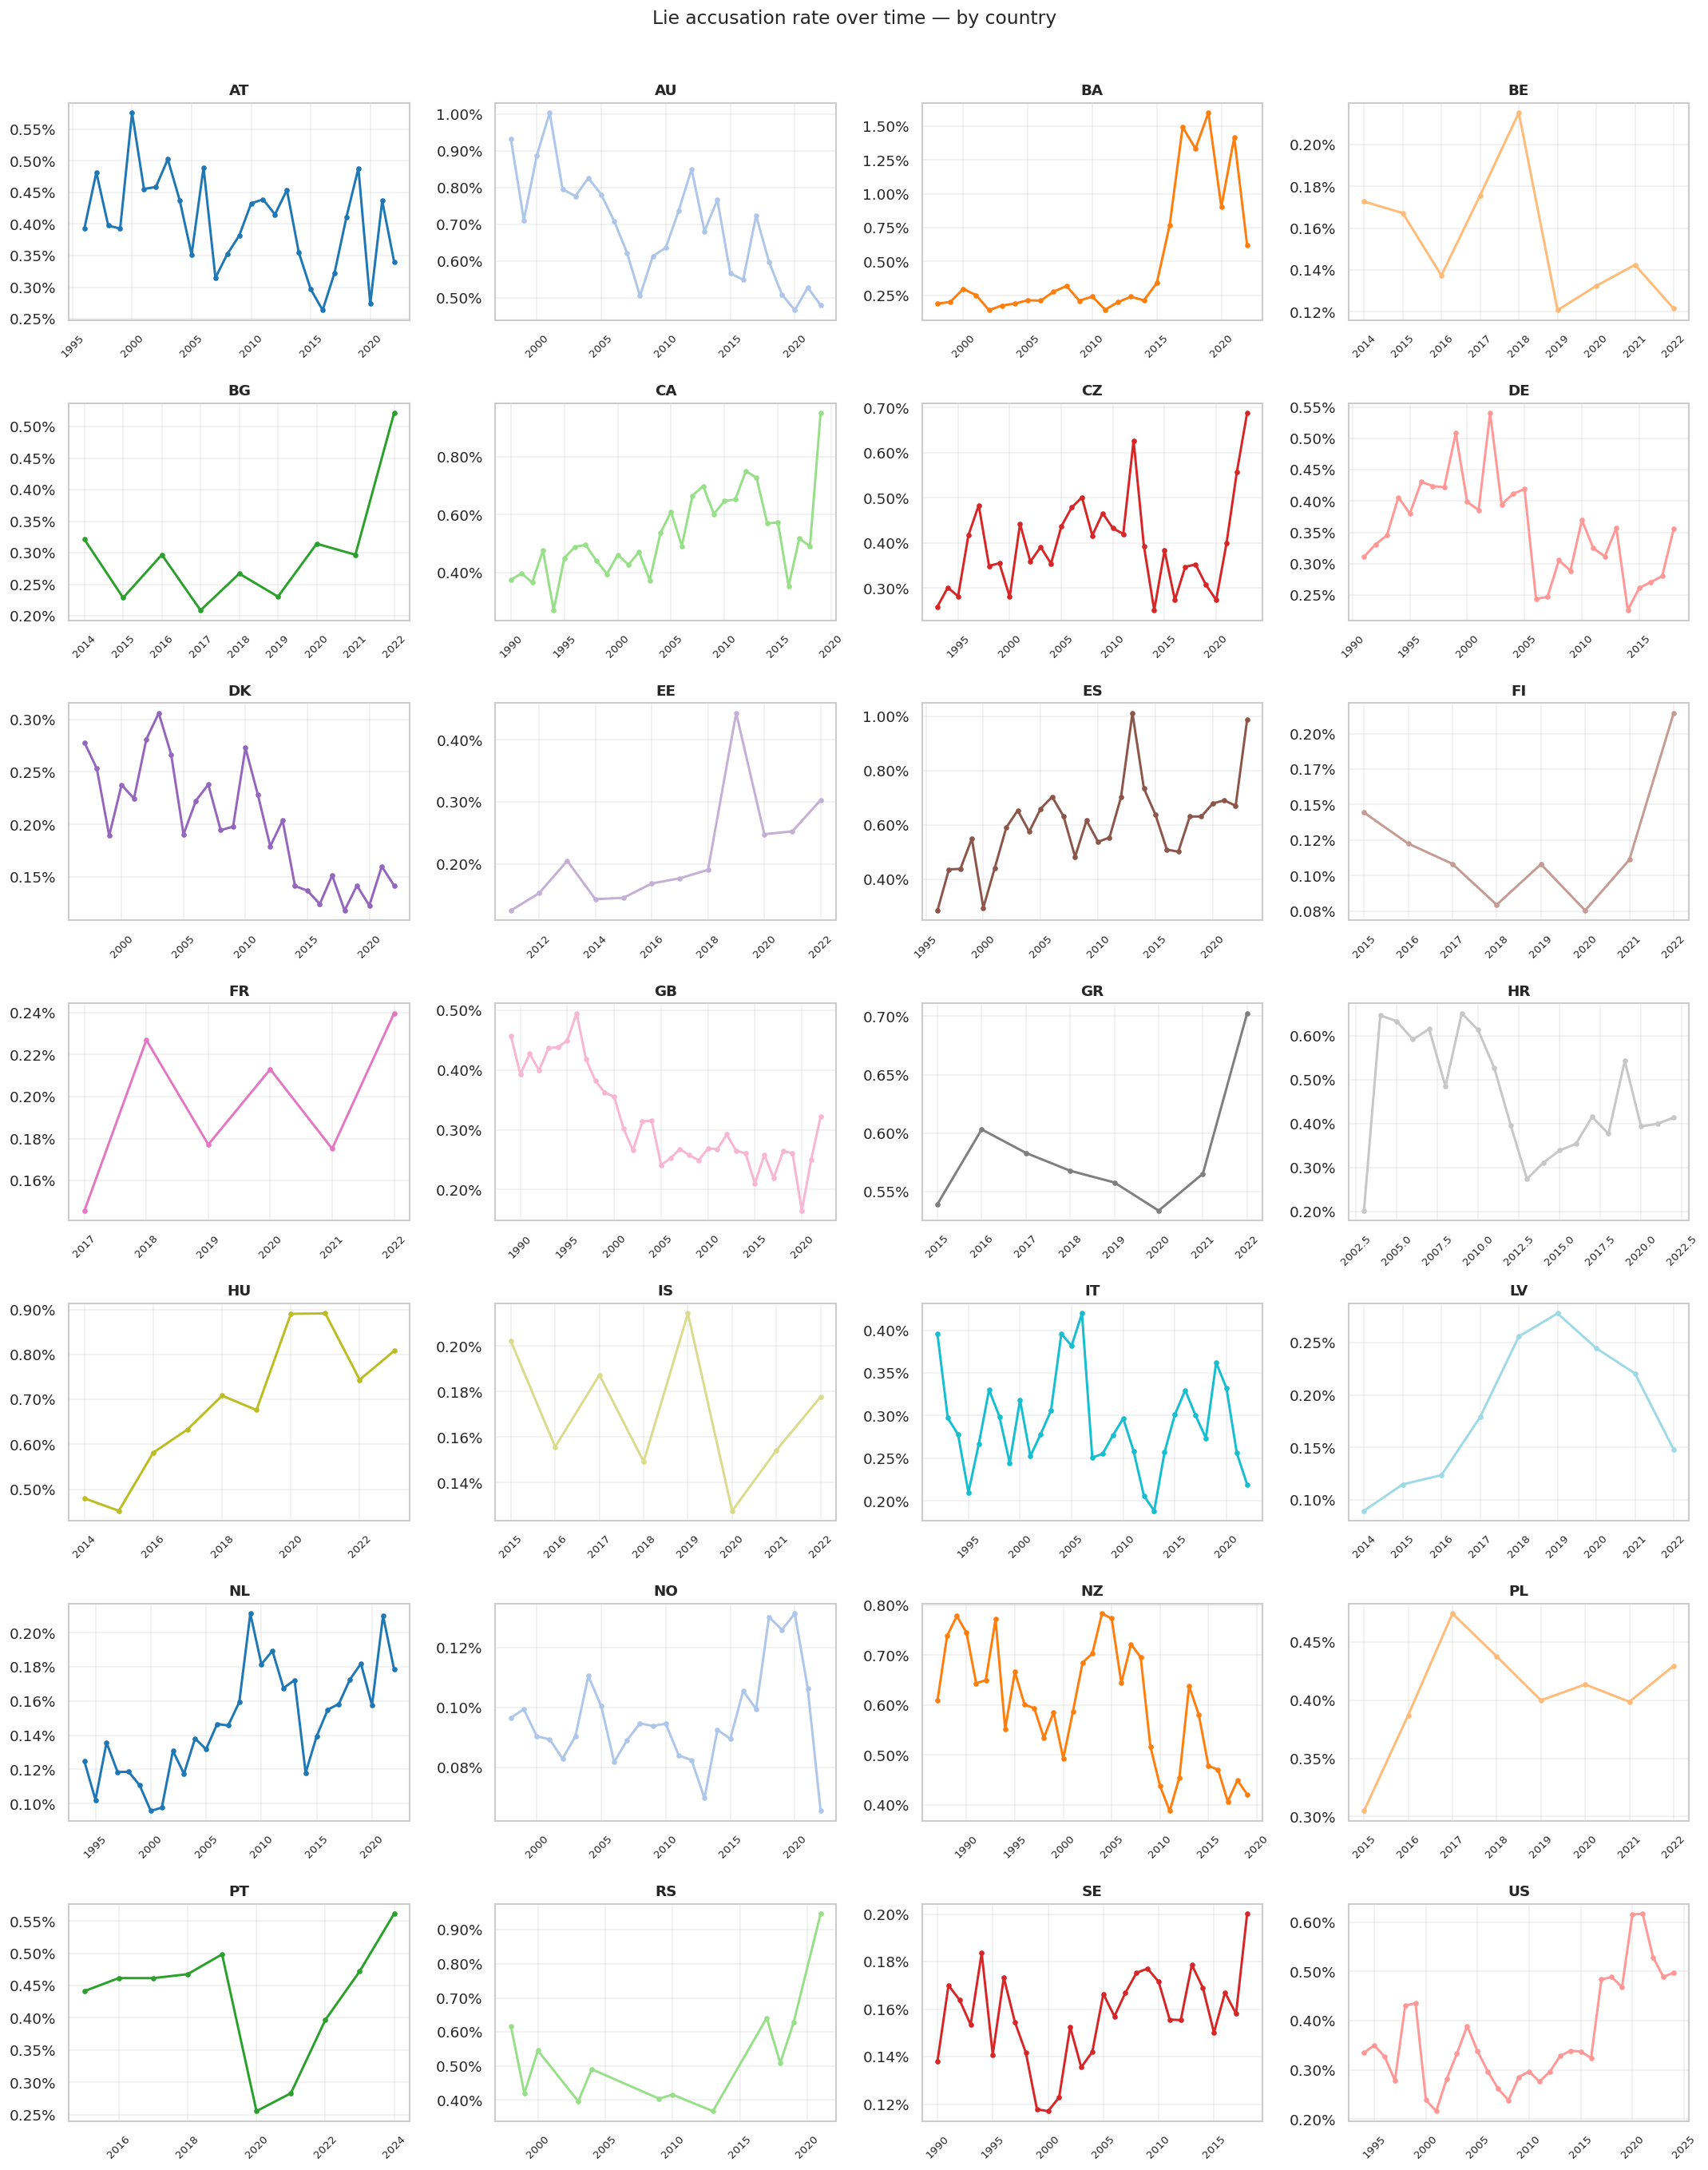

In [27]:
countries = sorted(df_cy['country'].unique())
ncols = 4
nrows = int(np.ceil(len(countries) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.2), sharey=False)
axes = axes.flatten()

palette = sns.color_palette('tab20', n_colors=len(countries))

for i, country in enumerate(countries):
    ax = axes[i]
    sub = df_cy[df_cy['country'] == country].sort_values('year')
    ax.plot(sub['year'], sub['lie_rate'] * 100,
            marker='o', linewidth=1.8, markersize=3, color=palette[i])
    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Lie accusation rate over time — by country', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('lie_rate_by_country_over_time.png', bbox_inches='tight')
plt.show()

## 5. Lie rate by source dataset

In [28]:
ds_agg = {}

for chunk in pd.read_csv(
    PRED_FILE,
    usecols=['source_dataset', 'source_dataset_type', 'lie_label'],
    chunksize=CHUNK_SIZE,
):
    chunk['is_lie'] = (chunk['lie_label'] == LIE_LABEL).astype(int)
    grp = chunk.groupby(['source_dataset', 'source_dataset_type'])['is_lie'].agg(['count', 'sum'])
    for (ds, dt), row in grp.iterrows():
        key = (ds, dt)
        if key not in ds_agg:
            ds_agg[key] = [0, 0]
        ds_agg[key][0] += row['count']
        ds_agg[key][1] += row['sum']

df_ds = pd.DataFrame(
    [(k[0], k[1], v[0], v[1]) for k, v in ds_agg.items()],
    columns=['source_dataset', 'source_dataset_type', 'total', 'lies']
)
df_ds['lie_rate'] = df_ds['lies'] / df_ds['total']
df_ds = df_ds.sort_values('lie_rate', ascending=False)
print(df_ds.to_string(index=False))

      source_dataset  source_dataset_type    total  lies  lie_rate
  australian-hansard   australian-hansard  7061204 49002  0.006940
        ParlaMint-HU            parlamint  1754138 11779  0.006715
        ParlaMint-ES            parlamint  2906846 18101  0.006227
            Congreso           parlspeech  2028670 12187  0.006007
               NZHoR           parlspeech  6440641 38362  0.005956
        ParlaMint-GR            parlamint  2808866 15895  0.005659
        ParlaMint-RS            parlamint  2035132 10672  0.005244
               lipad              hansard  9412815 48741  0.005178
        ParlaMint-HR            parlamint  4386165 20146  0.004593
        ParlaMint-PT            parlamint  1128141  4716  0.004180
                 PSP           parlspeech  1656044  6913  0.004174
        ParlaMint-PL            parlamint  2836437 11823  0.004168
        ParlaMint-AT            parlamint  4095440 16724  0.004084
        ParlaMint-BA            parlamint   999666  3971  0.00

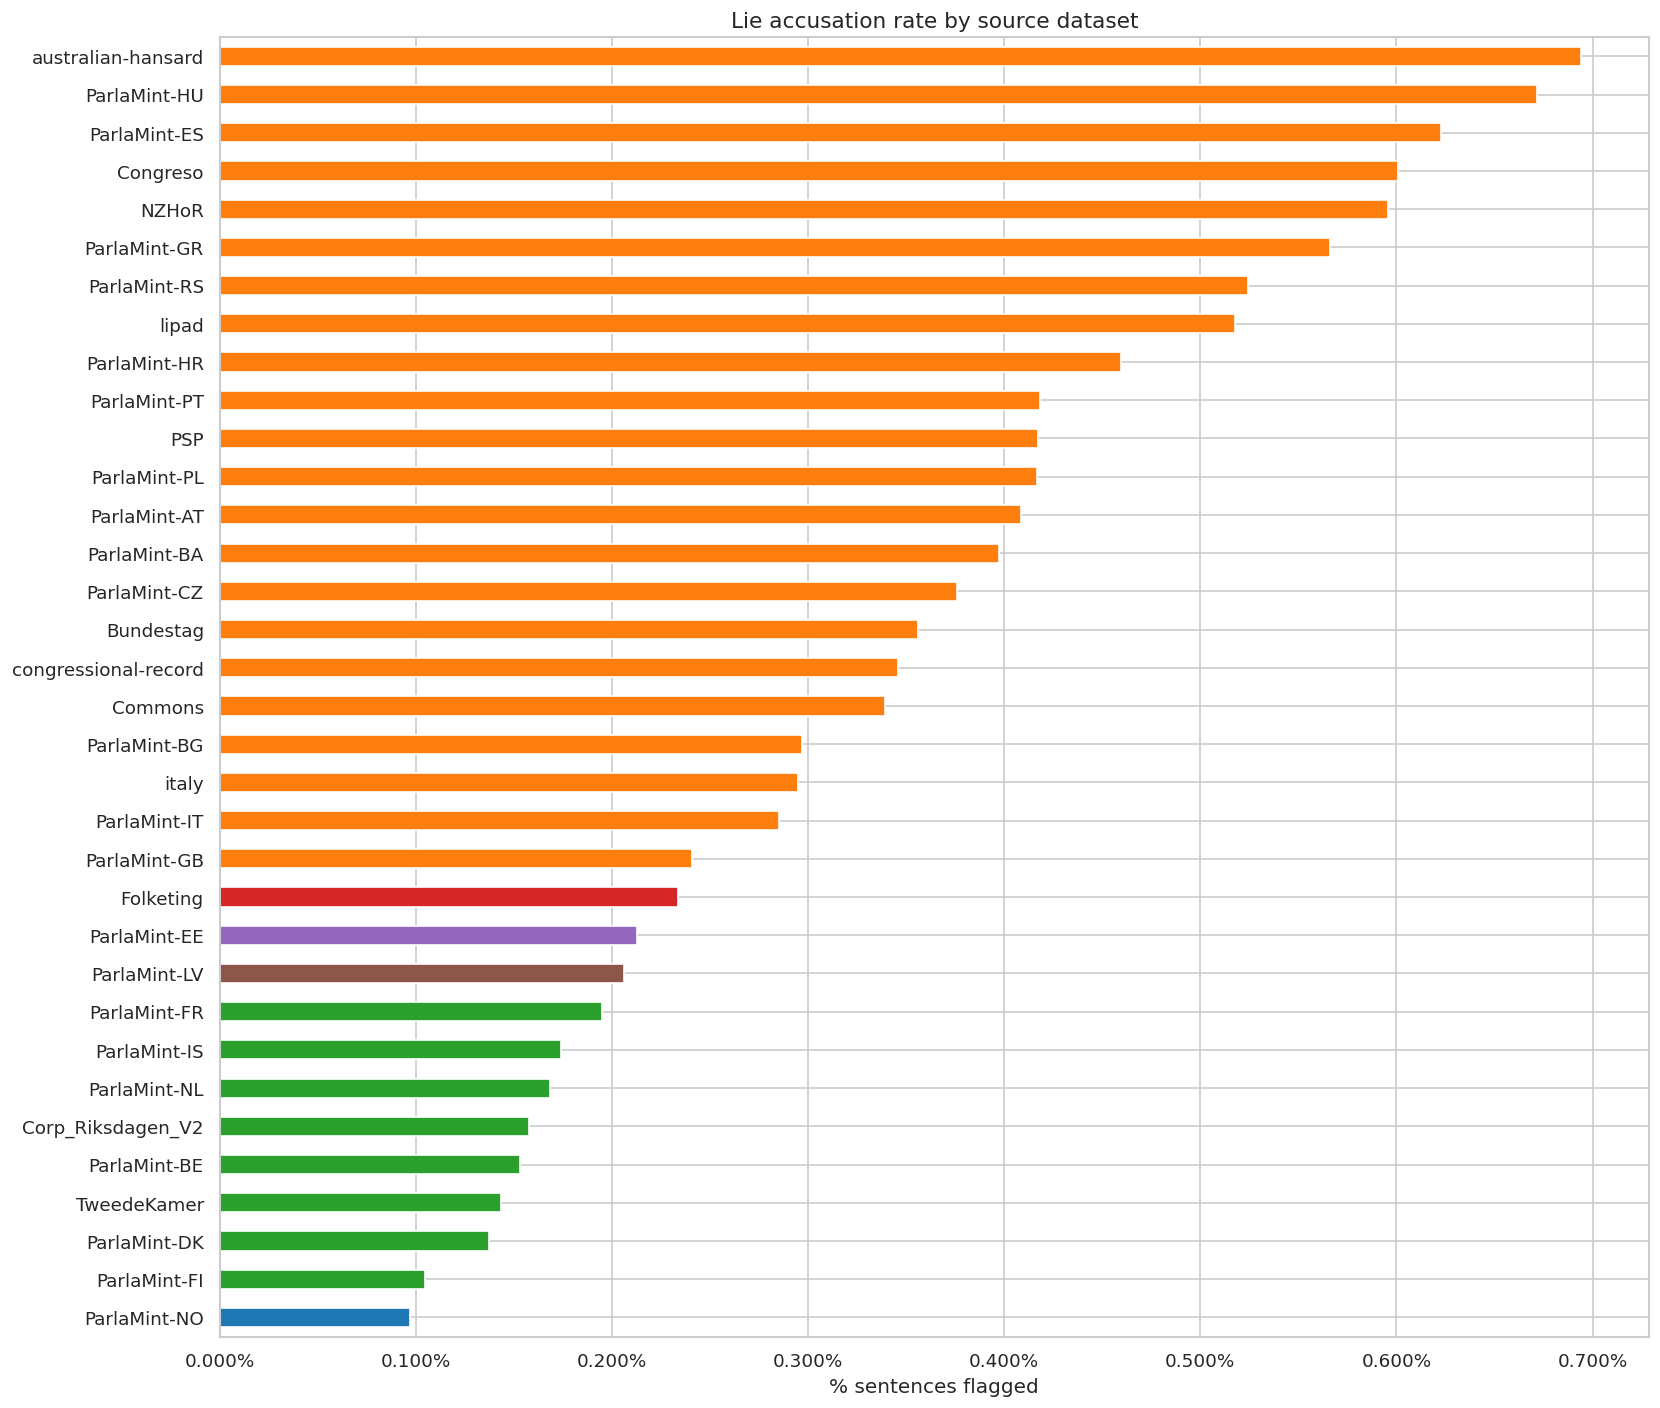

In [29]:
fig, ax = plt.subplots(figsize=(14, max(5, len(df_ds) * 0.35)))
colors = df_ds['source_dataset_type'].map(
    {t: c for t, c in zip(df_ds['source_dataset_type'].unique(),
                          sns.color_palette('tab10', n_colors=df_ds['source_dataset_type'].nunique()))}
)
df_ds.sort_values('lie_rate', ascending=True).plot(
    kind='barh', x='source_dataset', y='lie_rate', ax=ax,
    color=colors.sort_values().values, legend=False
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=3))
ax.set_title('Lie accusation rate by source dataset', fontsize=13)
ax.set_xlabel('% sentences flagged')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('lie_rate_by_dataset.png', bbox_inches='tight')
plt.show()

## 6. Score distribution

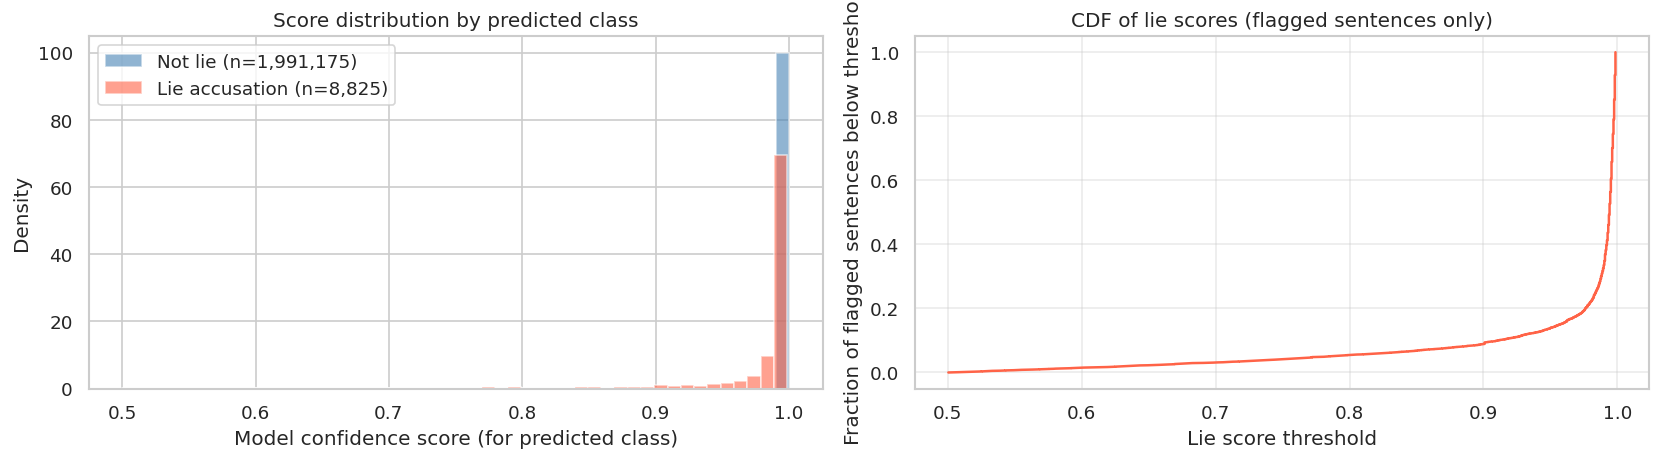

In [30]:
# Sample 2M rows for the score histogram (no need to scan the whole file)
df_scores = pd.read_csv(PRED_FILE, usecols=['lie_label', 'lie_score'], nrows=2_000_000)
df_scores['lie_score'] = pd.to_numeric(df_scores['lie_score'], errors='coerce')
df_scores = df_scores.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: score histogram for both classes
for label, color, name in [(NOTLIE_LABEL, 'steelblue', 'Not lie'), (LIE_LABEL, 'tomato', 'Lie accusation')]:
    subset = df_scores[df_scores['lie_label'] == label]['lie_score']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color,
                 label=f'{name} (n={len(subset):,})', density=True)
axes[0].set_xlabel('Model confidence score (for predicted class)')
axes[0].set_ylabel('Density')
axes[0].set_title('Score distribution by predicted class', fontsize=12)
axes[0].legend()

# Right: CDF of lie scores for flagged sentences
flagged_scores = df_scores[df_scores['lie_label'] == LIE_LABEL]['lie_score'].sort_values()
axes[1].plot(flagged_scores.values, np.linspace(0, 1, len(flagged_scores)), color='tomato')
axes[1].set_xlabel('Lie score threshold')
axes[1].set_ylabel('Fraction of flagged sentences below threshold')
axes[1].set_title('CDF of lie scores (flagged sentences only)', fontsize=12)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('lie_score_distribution.png', bbox_inches='tight')
plt.show()

## 7. Top-scoring examples

In [31]:
# Collect the top N highest-scoring lie sentences without loading the full file
import heapq

TOP_N = 50
top_heap = []  # min-heap of (score, row_dict)

for chunk in pd.read_csv(
    PRED_FILE,
    usecols=['sentence', 'date', 'speaker', 'country',
             'source_dataset', 'lie_label', 'lie_score'],
    chunksize=CHUNK_SIZE,
):
    chunk['lie_score'] = pd.to_numeric(chunk['lie_score'], errors='coerce')
    flagged = chunk[chunk['lie_label'] == LIE_LABEL].dropna(subset=['lie_score'])
    for _, row in flagged.iterrows():
        score = row['lie_score']
        entry = (score, row.to_dict())
        if len(top_heap) < TOP_N:
            heapq.heappush(top_heap, entry)
        elif score > top_heap[0][0]:
            heapq.heapreplace(top_heap, entry)

top_df = pd.DataFrame([x[1] for x in sorted(top_heap, reverse=True)])
top_df[['lie_score', 'country', 'date', 'speaker', 'source_dataset', 'sentence']]

TypeError: '<' not supported between instances of 'dict' and 'dict'

In [18]:
# Print top 20 for readability
print('=== TOP 20 HIGHEST-SCORING LIE ACCUSATIONS ===\n')
for i, row in top_df.head(20).iterrows():
    print(f"[{row['lie_score']:.4f}] {row['country']} | {row['date']} | {row['speaker']}")
    print(f"  {row['sentence']}")
    print()

NameError: name 'top_df' is not defined

## 8. Heatmap — lie rate by country × decade

In [ ]:
df_cy['decade'] = (df_cy['year'] // 10 * 10).astype(str) + 's'

pivot = df_cy.groupby(['country', 'decade']).apply(
    lambda x: x['lies'].sum() / x['total'].sum()
).unstack('decade') * 100

# Sort countries by overall lie rate
overall_order = df_country['lie_rate'].sort_values(ascending=False).index
pivot = pivot.reindex([c for c in overall_order if c in pivot.index])

fig, ax = plt.subplots(figsize=(max(8, pivot.shape[1] * 1.5), max(5, pivot.shape[0] * 0.5)))
sns.heatmap(
    pivot, ax=ax, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, cbar_kws={'label': '% sentences flagged'}
)
ax.set_title('Lie accusation rate (%) — country × decade', fontsize=13)
ax.set_xlabel('Decade')
ax.set_ylabel('Country')
plt.tight_layout()
plt.savefig('lie_rate_heatmap.png', bbox_inches='tight')
plt.show()